# TASK 1A

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv('ODI-2026.csv', sep=';', encoding='utf-8-sig')

In [76]:
#Show the number of rows and columns
print("Shape: ", df.shape)

Shape:  (156, 16)


In [77]:
#Show the column names and the data type of each column
print("\nColumn names:\n", df.columns.tolist())
print("\nData types: \n",df.dtypes)


Column names:
 ['Tijdstempel', 'What programme are you in?', 'Have you taken a course on machine learning?', 'Have you taken a course on information retrieval?', 'Have you taken a course on statistics?', 'Have you taken a course on databases?', 'What is your gender?', 'I have used LLMs to help me with some of my study assignments ', 'When is your birthday (date)?', 'How many students do you estimate there are in the room?', 'What is your stress level (0-100)?', 'How many hours per week do you do sports (in whole hours)? ', 'Give a random number', 'Time you went to bed Yesterday', 'What makes a good day for you (1)?', 'What makes a good day for you (2)?']

Data types: 
 Tijdstempel                                                       object
What programme are you in?                                        object
Have you taken a course on machine learning?                      object
Have you taken a course on information retrieval?                 object
Have you taken a course on st

##### The columns: Tijdstempel, Birthday date, Number of students, Stresslevel, Hours per week sports, Random number and Time went to bed are actually numbers and supposed to be integer, floats or datetime, but are actually objects (text) in the file. 

In [78]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Tijdstempel,What programme are you in?,Have you taken a course on machine learning?,Have you taken a course on information retrieval?,Have you taken a course on statistics?,Have you taken a course on databases?,What is your gender?,I have used LLMs to help me with some of my study assignments,When is your birthday (date)?,How many students do you estimate there are in the room?,What is your stress level (0-100)?,How many hours per week do you do sports (in whole hours)?,Give a random number,Time you went to bed Yesterday,What makes a good day for you (1)?,What makes a good day for you (2)?
0,3-31-2026 12:20:14,AI,yes,0,mu,nee,non-binary,yes,27/6/2001,200,0,10,67,3:30,Pagga,Pagga
1,3-31-2026 12:20:19,AI,yes,1,mu,ja,male,no,31.01.97,500,20,0,42,24:00,Sun,No rain
2,3-31-2026 12:20:20,"Masters in Science, Artificial Intelligence",yes,0,mu,ja,male,yes,15-03-2001,120,70,2,42,4,Productive Day,Indulging in Hobbies
3,3-31-2026 12:20:34,Systems biology & bioinformatics,yes,0,mu,ja,female,yes,5 November,310,0,8,67,22:00,Social interactions,Good weather
4,3-31-2026 12:20:39,AI,yes,1,mu,ja,female,yes,14-01-2002,250,30,7,55,22.15,Sun,Sports


We see that the values in the columns are not consistent; numbers, names, time, age. Almost every columns consists of data of different format. This might be the reason why the formats are all objects: since the columns consist variables of different formats, Pandas is forced to treat the variables in every column as text. 

In [79]:
#Check for missing values in the entire dataset; we know from above: Rows=156 and Columns=16
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 16 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   Tijdstempel                                                     156 non-null    object
 1   What programme are you in?                                      156 non-null    object
 2   Have you taken a course on machine learning?                    156 non-null    object
 3   Have you taken a course on information retrieval?               156 non-null    object
 4   Have you taken a course on statistics?                          156 non-null    object
 5   Have you taken a course on databases?                           156 non-null    object
 6   What is your gender?                                            156 non-null    object
 7   I have used LLMs to help me with some of my study assignments 

This seems correct. I also checked the excel file. There are no Null-values. There are "Unknown"-values in certain rows, so data is missing, but no empty cells.

In [80]:
#Analyse the data for empty strings
print("Empty strings per column:")
print((df == '').sum())

Empty strings per column:
Tijdstempel                                                       0
What programme are you in?                                        0
Have you taken a course on machine learning?                      0
Have you taken a course on information retrieval?                 0
Have you taken a course on statistics?                            0
Have you taken a course on databases?                             0
What is your gender?                                              0
I have used LLMs to help me with some of my study assignments     0
When is your birthday (date)?                                     0
How many students do you estimate there are in the room?          0
What is your stress level (0-100)?                                0
How many hours per week do you do sports (in whole hours)?        0
Give a random number                                              0
Time you went to bed Yesterday                                    0
What makes a good day 

In [81]:
#Check for placeholder-values in the rows instead of leaving fields blank
print("\n'Unknown' values per column:")
print((df == 'unknown').sum())


'Unknown' values per column:
Tijdstempel                                                        0
What programme are you in?                                         0
Have you taken a course on machine learning?                       1
Have you taken a course on information retrieval?                 15
Have you taken a course on statistics?                            10
Have you taken a course on databases?                              3
What is your gender?                                               0
I have used LLMs to help me with some of my study assignments      0
When is your birthday (date)?                                      0
How many students do you estimate there are in the room?           0
What is your stress level (0-100)?                                 0
How many hours per week do you do sports (in whole hours)?         0
Give a random number                                               0
Time you went to bed Yesterday                                     0
What

Findings: there are 29 cell-values in total across the dataset where these no-data cells are marked as "unknown". 

In [82]:
#statistical summary of the columns
df.describe(include='all')

,Tijdstempel,What programme are you in?,Have you taken a course on machine learning?,Have you taken a course on information retrieval?,Have you taken a course on statistics?,Have you taken a course on databases?,What is your gender?,I have used LLMs to help me with some of my study assignments,When is your birthday (date)?,How many students do you estimate there are in the room?,What is your stress level (0-100)?,How many hours per week do you do sports (in whole hours)?,Give a random number,Time you went to bed Yesterday,What makes a good day for you (1)?,What makes a good day for you (2)?
count,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156,156
unique,96,75,3,3,3,3,5,3,153,55,44,22,95,94,119,136
top,3-31-2026 12:21:52,AI,yes,0,mu,ja,male,yes,2002,200,30,2,67,00:30,Sun,Good food
freq,5,25,134,83,122,107,79,115,2,17,17,21,16,10,12,5


###### count = number of rows, unique = number of different values, top = the most frequent occuring value, freq = number of times that the top value occurs.

You can see in the output the following:
1. different languages; this needs to be standardized
2. birthday has 156 rows and 153 unique variables
3. supprisingly are the randomn numbers not so randomn, with 67 occuring 16 times.
4. There are 75 unique programmes, thats a bit much, probably because of names like AI, A.I., Ai, Artificial Inteligence, BA, Business Analytics etc

# Plots

Before being able to make some plots, we need to convert the columns type of certain columns.

In [83]:
# Convert values in the column Stress Level tot numbers, if an error occurs, set the value to NaN
stress = pd.to_numeric(df['What is your stress level (0-100)?'], errors='coerce')


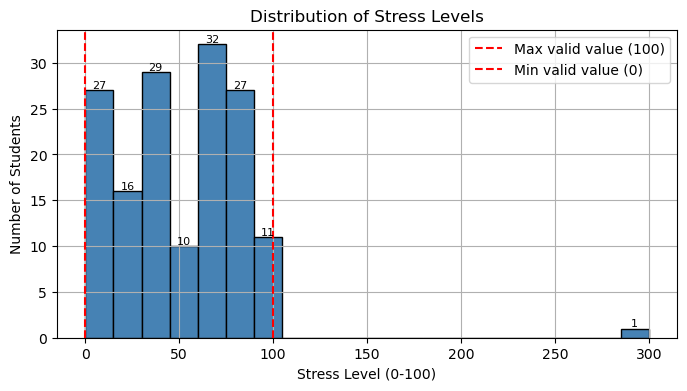

In [84]:
# Plot distribution
plt.figure(figsize=(8, 4))
ax = plt.gca()
stress.hist(bins=20, color='steelblue', edgecolor='black', ax=ax)

plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level (0-100)')
plt.ylabel('Number of Students')

plt.axvline(x=100, color='red', linestyle='--', label='Max valid value (100)')
plt.axvline(x=0, color='red', linestyle='--', label='Min valid value (0)')

# Add number on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.legend()
plt.show()


The stresslevel was required to be between 0 up to 100, but there are also values beyond 100. Especially the 300 is an outliers.

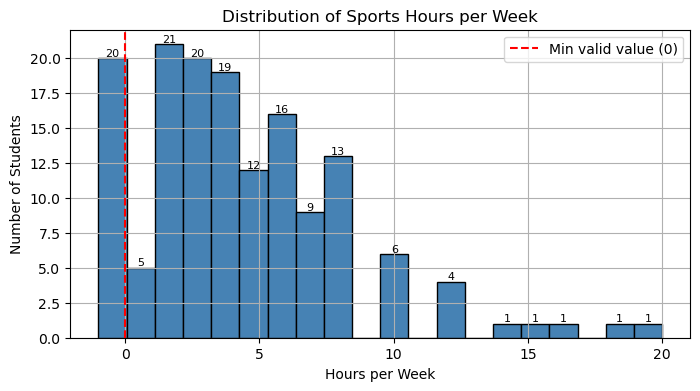

In [85]:
# Convert sportshours to number, force errors to NaN
sports = pd.to_numeric(df['How many hours per week do you do sports (in whole hours)? '], errors='coerce')

# Plot the distribution
plt.figure(figsize=(8, 4))
ax = plt.gca()
sports.hist(bins=20, color='steelblue', edgecolor='black', ax=ax)

#plt.axvline(x=168, color='red', linestyle='--', label='Max valid value (168hrs = 1 week)')
plt.axvline(x=0, color='red', linestyle='--', label='Min valid value (0)')

# Add number on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.legend()
plt.title('Distribution of Sports Hours per Week')
plt.xlabel('Hours per Week')
plt.ylabel('Number of Students')
plt.show()


There are students who sport negative hours in a week

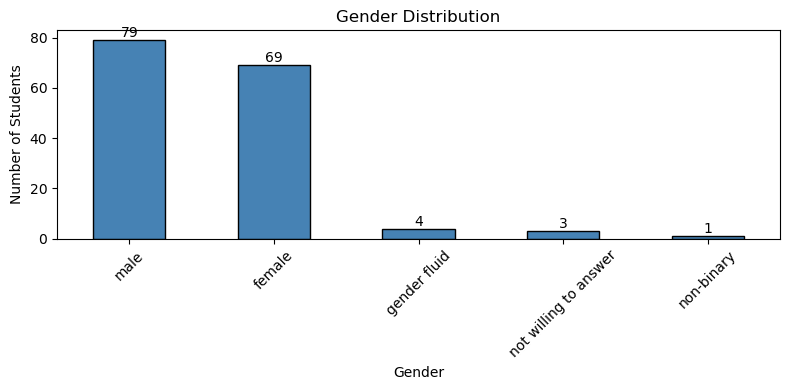

In [86]:
# Count occurrences of each gender value
gender_counts = df['What is your gender?'].value_counts()

# Plot bar chart
plt.figure(figsize=(8, 4))
ax = gender_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)

# Add number on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


The dataset contains 5 gender categories: male, female, gender fluid, not willing to answer, and non-binary
The majority identifies as male (79) or female (69).
The values are consistent, in contrary to the other columns.

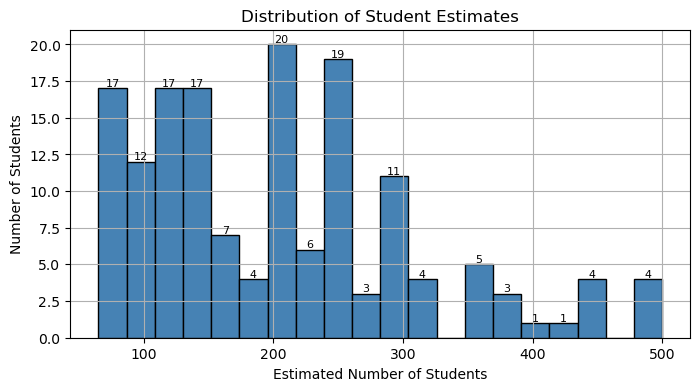

In [87]:
# Convert student estimates to numeric
students = pd.to_numeric(df['How many students do you estimate there are in the room?'], errors='coerce')

# Plot distribution
plt.figure(figsize=(8, 4))
ax = plt.gca()
students.hist(bins=20, color='steelblue', edgecolor='black', ax=ax)

# Add number on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.title('Distribution of Student Estimates')
plt.xlabel('Estimated Number of Students')
plt.ylabel('Number of Students')
plt.show()


Estimates range from 65 to 500 students.
The numbers 200 and 250 are the most common answers (17 and 16 students respectively), suggesting people rounded to nice numbers rather than giving precise estimates.
The number 500 appears 4 times, an very high number for a single lecture room.
The wide spread (65–500) shows high uncertainty in crowd estimation.

# TASK 1B

For task 1B we'll make a copy of the file so the original stays untouched.

In [88]:
# Work on a copy so the original data is preserved
df_clean = df.copy()

# Convert to numeric to detect outliers
df_clean['stress'] = pd.to_numeric(df_clean['What is your stress level (0-100)?'], errors='coerce')
df_clean['sports'] = pd.to_numeric(df_clean['How many hours per week do you do sports (in whole hours)? '], errors='coerce')

# Print outliers
print("Stress outliers (outside 0-100):")
print(df_clean[df_clean['stress'] > 100]['stress'])

print("\nSports outliers (negative values):")
print(df_clean[df_clean['sports'] < 0]['sports'])

Stress outliers (outside 0-100):
12    101.0
14    101.0
39    300.0
Name: stress, dtype: float64

Sports outliers (negative values):
12   -1.0
Name: sports, dtype: float64


In [89]:
# Set invalid stress values to NaN
df_clean.loc[df_clean['stress'] > 100, 'stress'] = None

# Set invalid sports values to NaN
df_clean.loc[df_clean['sports'] < 0, 'sports'] = None

print("Stress NaN count after cleaning:", df_clean['stress'].isna().sum())
print("Sports NaN count after cleaning:", df_clean['sports'].isna().sum())

Stress NaN count after cleaning: 6
Sports NaN count after cleaning: 7


Stress: 6 NaN total after cleaning.
- 3 outliers removed (101, 101, 300) — outside valid range 0-100
- 3 non-numeric entries (e.g. "Yes", "9.999.999", "100 😳") converted to NaN

Sports: 7 NaN total after cleaning.
- 1 outlier removed (-1) — negative hours are physically impossible
- 6 non-numeric entries (e.g. "5-6 hours", "1hr") converted to NaN

In [90]:
# Check what the original non-numeric stress values were
mask = pd.to_numeric(df['What is your stress level (0-100)?'], errors='coerce').isna()
print(df[mask]['What is your stress level (0-100)?'])


55           Yes
79     9.999.999
148        100 😳
Name: What is your stress level (0-100)?, dtype: object


In [94]:
#handle first the numerical imputation, afterwards the categorical.

# Store original NaN positions for comparison
stress_nan_idx = df_clean[df_clean['stress'].isna()].index
sports_nan_idx = df_clean[df_clean['sports'].isna()].index

# --- Approach 1: Mean imputation ---
df_mean = df_clean.copy()
df_mean['stress'] = df_mean['stress'].fillna(df_mean['stress'].mean())
df_mean['sports'] = df_mean['sports'].fillna(df_mean['sports'].mean())

# --- Approach 2: Median imputation ---
df_median = df_clean.copy()
df_median['stress'] = df_median['stress'].fillna(df_median['stress'].median())
df_median['sports'] = df_median['sports'].fillna(df_median['sports'].median())

# Compare the imputed values
print("Stress — Mean imputed values:")
print(df_mean.loc[stress_nan_idx, 'stress'].round(2).values)
print("\nStress — Median imputed values:")
print(df_median.loc[stress_nan_idx, 'stress'].round(2).values)

print("\nSports — Mean imputed values:")
print(df_mean.loc[sports_nan_idx, 'sports'].round(2).values)
print("\nSports — Median imputed values:")
print(df_median.loc[sports_nan_idx, 'sports'].round(2).values)



Stress — Mean imputed values:
[47.19 47.19 47.19 47.19 47.19 47.19]

Stress — Median imputed values:
[50. 50. 50. 50. 50. 50.]

Sports — Mean imputed values:
[4.68 4.68 4.68 4.68 4.68 4.68 4.68]

Sports — Median imputed values:
[4. 4. 4. 4. 4. 4. 4.]


Numerical imputation comparison:

Stress: mean = 47.19, median = 50.0
Sports: mean = 4.68, median = 4.0

We choose median imputation because the stress distribution is skewed (visible in the histogram) and had outliers (300, 101), which inflate the mean. The median is more robust to outliers. For sports the difference is small, but median is preferred for consistency.
